# M06 — Two-Phase Fine-Tuning

**EEEM068 Applied Machine Learning — MaxViT-Tiny Optimisation Series (M06 of 8)**

Take M05 and test whether a short head-only warm-up phase, before unfreezing the full backbone, protects MaxViT's pretrained representations and improves validation performance relative to single-stage fine-tuning.

This notebook uses the same leakage-free patient-grouped split and the same P0 preprocessing
as the EfficientNet-B4 architecture comparison, so results stay comparable across
architectures. **The internal test set is not loaded or evaluated anywhere in this
notebook** — only validation results are produced here; the test set stays locked until a
final configuration is selected across M01-M08.

## 2. Hypothesis and change from previous experiment

Copied from **M05** (`M05_safe_retinal_augmentation.ipynb`). M05 is the direct predecessor and achieved validation QWK 0.7505, macro-F1 0.5596, balanced accuracy 0.5509, Mild recall 0.1467 and Mild F1 0.1649.

M06 retains M05's architecture, loss, augmentation, patient-grouped split, preprocessing and evaluation protocol. The training strategy changes to a three-epoch head-only phase followed by full-model fine-tuning.

The experiment evaluates whether two-phase fine-tuning improves generalisation while preserving or improving M05's Mild-DR recognition. Phase-2 head and backbone learning rates are both kept at 5e-5 — the same value M05 used throughout — so that differential learning rates are not introduced as a second, uncontrolled change alongside the training strategy. MaxViT is a **hybrid** architecture: its MBConv blocks contain real BatchNorm layers alongside attention blocks' LayerNorm, so Phase 1 genuinely needs the `head_only=True` BatchNorm-freeze mechanism (Section 14), unlike a pure-transformer model.

**Question this experiment answers:** Does head warm-up protect MaxViT's pretrained representations and improve validation performance over single-stage fine-tuning (M05)?

## 3. Imports

In [1]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

print("Imports OK.")

Imports OK.


## 4. Experiment configuration

Two-phase training: Phase 1 trains only the classification head for a fixed 3 epochs at
`PHASE1_HEAD_LR`; Phase 2 unfreezes the whole model and fine-tunes for up to
`PHASE2_MAX_EPOCHS` more epochs, using `BACKBONE_LR` for the backbone and `HEAD_LR` for the
head. `MAX_EPOCHS` (25) is recorded for comparability with the single-stage notebooks even
though it is never used directly as a loop bound here.

This section runs immediately after imports and before reproducibility/paths, because
`SEED` is defined here and the reproducibility cell (Section 5) depends on it — running
`set_seed()` before `SEED` exists would raise a `NameError`. `RUN_NAME` and `EXPERIMENT_ID`
are also defined only here, not repeated in the paths cell, so the experiment identifiers can
be updated in one configuration cell when creating the next notebook.

`CLASS_WEIGHT_METHOD`, `CLASS_WEIGHT_CLIP_MIN` and `CLASS_WEIGHT_CLIP_MAX` are set here too, alongside `USE_CLASS_WEIGHTS`/`USE_WRS` — the loss cell (Section 11) reads these values rather than hard-coding its own copy, so the clip range only ever needs to be changed in one place.

The safe-retinal augmentation policy's exact parameters (`HORIZONTAL_FLIP_PROBABILITY`, `ROTATION_DEGREES`, the four `*_JITTER` values, `TRANSLATE_FRACTION`, `SCALE_MIN`/`SCALE_MAX`) are also set here, rather than hard-coded inside the transform (Section 9) — so the exact augmentation policy used is visible in one place and recorded automatically in `config.json`.

In [2]:
EXPERIMENT_ID = "M06"
RUN_NAME = "M06_two_phase_finetuning"

MODEL_NAME = "maxvit_tiny_tf_224.in1k"
IMAGE_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
SEED = 42

VIT_MEAN = (0.485, 0.456, 0.406)
VIT_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 32
WEIGHT_DECAY = 0.05

BACKBONE_LR = 5e-05
# Keep the full-model Phase-2 learning rate identical to M05.
HEAD_LR = 5e-5

PHASE1_EPOCHS = 3
PHASE1_HEAD_LR = 1e-4

PHASE2_MAX_EPOCHS = 22

# Keep patience consistent with the single-stage notebooks.
PHASE2_PATIENCE = 7

MAX_EPOCHS = PHASE1_EPOCHS + PHASE2_MAX_EPOCHS
LEARNING_RATE = BACKBONE_LR
WARMUP_EPOCHS = PHASE1_EPOCHS

LABEL_SMOOTHING = 0.0
GRAD_CLIP = 1.0
QWK_TOLERANCE = 1e-4
NUM_WORKERS = 4
EARLY_STOPPING_PATIENCE = PHASE2_PATIENCE
TRAINING_MODE = "two_phase"
EXPERIMENT_TYPE = "training_strategy_ablation"

USE_CLASS_WEIGHTS = True
USE_WRS = False
CLASS_WEIGHT_METHOD = "balanced"
CLASS_WEIGHT_CLIP_MIN = 0.5
CLASS_WEIGHT_CLIP_MAX = 2.5

HORIZONTAL_FLIP_PROBABILITY = 0.5
ROTATION_DEGREES = 7
BRIGHTNESS_JITTER = 0.05
CONTRAST_JITTER = 0.05
SATURATION_JITTER = 0.02
HUE_JITTER = 0.0
TRANSLATE_FRACTION = 0.02
SCALE_MIN = 0.98
SCALE_MAX = 1.02

print(f"Experiment : {EXPERIMENT_ID} / {RUN_NAME}")
print(f"Phase 1: {PHASE1_EPOCHS} epochs, head LR={PHASE1_HEAD_LR} (backbone frozen)")
print(f"Phase 2: max {PHASE2_MAX_EPOCHS} epochs, backbone LR={BACKBONE_LR}, "
      f"head LR={HEAD_LR}, patience={PHASE2_PATIENCE}")
print(f"BATCH={BATCH_SIZE}  WD={WEIGHT_DECAY}")

Experiment : M06 / M06_two_phase_finetuning
Phase 1: 3 epochs, head LR=0.0001 (backbone frozen)
Phase 2: max 22 epochs, backbone LR=5e-05, head LR=5e-05, patience=7
BATCH=32  WD=0.05


## 5. Reproducibility and device

Full seeding across Python/NumPy/PyTorch/CUDA, a seeded per-worker `DataLoader` RNG, and a
hard failure if no CUDA GPU is available. This must run after Section 4, since `set_seed()`
takes `SEED` as its default argument.

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 6. Paths and output directories

Points at the same `configs/splits/` manifests used by the EfficientNet notebooks. This
notebook's own logs, checkpoints and figures are written to a run-specific subfolder (named
from `RUN_NAME`, defined in Section 4) so no other M01-M08 notebook's outputs are ever
overwritten.

In [4]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
# The internal test split is intentionally not loaded anywhere in this
# notebook. It stays locked until a final MaxViT configuration is selected
# across M01-M08.

RUN_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / RUN_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / RUN_NAME
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "maxvit_tiny" / RUN_NAME

for directory in [RUN_LOG_DIR, CHECKPOINT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best.pt"
PHASE1_BEST_PATH = CHECKPOINT_DIR / "phase1_best.pt"

print(f"Run          : maxvit_tiny/{RUN_NAME}")
print(f"Logs         -> {RUN_LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")

Run          : maxvit_tiny/M06_two_phase_finetuning
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M06_two_phase_finetuning
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/maxvit_tiny/M06_two_phase_finetuning
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M06_two_phase_finetuning


## 7. Load patient-grouped CSV files

Only `train_split.csv` and `val_split.csv` are loaded — the internal test split is
intentionally absent from this notebook entirely.

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_columns = {"image", "level", "patient_id", "eye", "filepath"}

for split_name, frame in [("train", train_df), ("validation", val_df)]:
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{split_name} is missing columns: {sorted(missing_columns)}"
        )

    missing_files = frame.loc[
        ~frame["filepath"].map(lambda path: Path(path).exists())
    ]
    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains {len(missing_files):,} missing image files."
        )

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")

Train      : 24,586
Validation : 5,270


## 8. Verify zero patient overlap

In [6]:
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])

assert train_patients.isdisjoint(val_patients), (
    "Patient overlap detected between train and validation splits."
)

print(f"Train patients      : {len(train_patients):,}")
print(f"Validation patients : {len(val_patients):,}")
print("Patient overlap check: PASSED (zero overlap)")

Train patients      : 12,293
Validation patients : 2,635
Patient overlap check: PASSED (zero overlap)


## 9. Dataset class and transformations

`DRDataset` applies P0 preprocessing on the fly and returns `(image, label, index)`, so
predictions can be matched back to source rows later. Uses the **safe retinal augmentation** policy: small ±7° rotation, mild colour jitter, small affine jitter, horizontal flip. No vertical flips, no aggressive cropping, no Mixup, no random erasing. Every parameter of this policy is read from the named variables set in Section 4, not hard-coded here. The evaluation transform is
a plain resize + normalise with no augmentation.

In [7]:
def _load_rgb(path: str) -> np.ndarray:
    """Load an image file and return it as an RGB uint8 array."""
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    """Crop the uninformative black padding around the retinal disc."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    """Pad an image onto a centred square canvas (no resizing yet)."""
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def preprocess_p0(image_path: str, output_size: int = IMAGE_SIZE) -> np.ndarray:
    """P0: crop black borders, pad to square, resize. Same pipeline used for
    the EfficientNet-B4 architecture comparison, kept identical here so
    architecture comparisons are not confounded by preprocessing differences."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    img = _pad_square(img)
    return cv2.resize(img, (output_size, output_size), interpolation=cv2.INTER_AREA)


print(f"P0 preprocessing ready. Output size: {IMAGE_SIZE}x{IMAGE_SIZE}, RGB, uint8.")

P0 preprocessing ready. Output size: 224x224, RGB, uint8.


In [8]:
class DRDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image = preprocess_p0(row["filepath"])
        image = Image.fromarray(image)

        label = int(row["level"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, index

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(
        p=HORIZONTAL_FLIP_PROBABILITY
    ),
    transforms.RandomAffine(
        degrees=ROTATION_DEGREES,
        translate=(
            TRANSLATE_FRACTION,
            TRANSLATE_FRACTION,
        ),
        scale=(SCALE_MIN, SCALE_MAX),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0,
    ),
    transforms.ColorJitter(
        brightness=BRIGHTNESS_JITTER,
        contrast=CONTRAST_JITTER,
        saturation=SATURATION_JITTER,
        hue=HUE_JITTER,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=VIT_MEAN,
        std=VIT_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])

train_ds = DRDataset(train_df, transform=train_transform)
val_ds = DRDataset(val_df, transform=eval_transform)

AUGMENTATION_CONFIG = {
    "policy": "safe_retinal_augmentation",
    "resize": [IMAGE_SIZE, IMAGE_SIZE],
    "horizontal_flip_probability": HORIZONTAL_FLIP_PROBABILITY,
    "geometric_transform": "single_random_affine",
    "interpolation": "bilinear",
    "rotation_degrees": ROTATION_DEGREES,
    "brightness_jitter": BRIGHTNESS_JITTER,
    "contrast_jitter": CONTRAST_JITTER,
    "saturation_jitter": SATURATION_JITTER,
    "hue_jitter": HUE_JITTER,
    "translation_fraction": TRANSLATE_FRACTION,
    "scale_min": SCALE_MIN,
    "scale_max": SCALE_MAX,
    "vertical_flip": False,
    "mixup": False,
    "random_erasing": False,
}

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,}")

train_ds: 24,586 | val_ds: 5,270


## 10. DataLoaders

M06 deliberately uses ordinary random shuffling for training, with no `WeightedRandomSampler`. Class imbalance is handled entirely through the clipped class-weighted loss (Section 11) instead — combining both a weighted sampler *and* a weighted loss would double-count the rebalancing effect. The validation loader always uses `shuffle=False` and receives no
balancing or augmentation of any kind, regardless of what the training loader does.

In [10]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 769 | Val batches: 165


## 11. Clipped class-weighted loss

M06 retains the exact clipped class-weighted cross-entropy used in M05.
Balanced class weights are calculated from the training split and clipped
to the range [0.5, 2.5].

Label smoothing remains 0.0, ordinary shuffled batches are used and no
WeightedRandomSampler is applied. The loss and balancing configuration are
therefore unchanged from M05.

In [11]:
raw_weights = compute_class_weight(
    class_weight=CLASS_WEIGHT_METHOD,
    classes=np.arange(NUM_CLASSES),
    y=train_df["level"].to_numpy(),
)

clipped_weights = np.clip(
    raw_weights,
    CLASS_WEIGHT_CLIP_MIN,
    CLASS_WEIGHT_CLIP_MAX,
)

class_weights = torch.tensor(
    clipped_weights,
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights if USE_CLASS_WEIGHTS else None,
    label_smoothing=LABEL_SMOOTHING,
)
LOSS_FUNCTION_LABEL = "clipped_class_weighted_cross_entropy"

print("Loss: Clipped class-weighted CrossEntropyLoss")
print("Raw balanced weights:", np.round(raw_weights, 3))
print("Clipped weights:", np.round(clipped_weights, 3))
print("Use class weights:", USE_CLASS_WEIGHTS)
print("Use WRS:", USE_WRS)
print("Label smoothing:", LABEL_SMOOTHING)

Loss: Clipped class-weighted CrossEntropyLoss
Raw balanced weights: [0.272 2.877 1.33  8.061 9.699]
Clipped weights: [0.5  2.5  1.33 2.5  2.5 ]
Use class weights: True
Use WRS: False
Label smoothing: 0.0


## 12. MaxViT-Tiny model

`timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)` — MaxViT exposes a
native `num_classes` argument, so no custom forward-method patching is needed here. Unlike a pure transformer, MaxViT is a *hybrid* architecture: each stage alternates MBConv (convolutional, with real BatchNorm) blocks with block/grid attention (LayerNorm) blocks — relevant later in Section 13/14, where Phase 1 needs to freeze BatchNorm running statistics as well as gradients.

In [12]:
def build_model(pretrained: bool = True) -> nn.Module:
    """Build MaxViT-Tiny with timm's native num_classes head."""
    return timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=NUM_CLASSES,
    ).to(device)


model = build_model(pretrained=True)

total_parameters = sum(p.numel() for p in model.parameters())

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_parameters:,}")

Model: maxvit_tiny_tf_224.in1k
Total parameters: 30,406,093


## 13. Optimiser and scheduler

Phase 1 uses an `AdamW` optimiser over only the classification-head
parameters at a constant learning rate. Phase 2 uses separate backbone and
head parameter groups, both with a learning rate of 5e-5, followed by
`CosineAnnealingLR`. Keeping both Phase-2 learning rates equal avoids
introducing differential learning rates as another experimental change.

In [13]:
def freeze_backbone(model: nn.Module) -> None:
    """Freeze every parameter except the classification head.

    Gradient freezing alone (requires_grad=False) is not a complete freeze for
    MaxViT: its MBConv blocks contain real BatchNorm layers that keep updating
    their running statistics during any model.train() forward pass regardless of
    requires_grad. run_epoch()'s head_only=True flag (Section 14) additionally
    forces every BatchNorm submodule into eval() mode during Phase 1 to close
    that gap - see set_batchnorm_eval().
    """
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("head")


def unfreeze_all(model: nn.Module) -> None:
    for param in model.parameters():
        param.requires_grad = True


freeze_backbone(model)
trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 trainable params: {trainable_p1:,} (head only, backbone frozen)")

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)

print(f"Phase 1 optimizer: AdamW(lr={PHASE1_HEAD_LR}), constant LR over "
      f"{PHASE1_EPOCHS} epochs (no scheduler needed for such a short warm-up stage)")

Phase 1 trainable params: 266,245 (head only, backbone frozen)
Phase 1 optimizer: AdamW(lr=0.0001), constant LR over 3 epochs (no scheduler needed for such a short warm-up stage)


## 14. Training and validation functions

`run_epoch()` disables gradient tracking entirely during evaluation, raises if a training
call is made without an optimizer, guards against an empty loader, and raises if QWK comes
back non-finite. For this two-phase notebook, `head_only=True` additionally forces every BatchNorm submodule into `eval()` mode during Phase 1 — see `set_batchnorm_eval()` below, needed because MaxViT's MBConv blocks contain real BatchNorm layers unlike a pure transformer. `checkpoint_improved()` implements the agreed selection rule
exactly: **validation QWK primary** (must improve by more than `QWK_TOLERANCE`),
**validation macro-F1 as tie-break** when QWK is within tolerance of the current best.

In [14]:
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def set_batchnorm_eval(module: nn.Module) -> None:
    """Prevent BatchNorm running statistics changing during head-only training.

    Unlike a pure transformer (DeiT/ViT), MaxViT is a *hybrid* architecture: its
    MBConv blocks are genuine convolutional layers with real BatchNorm layers,
    interleaved with attention blocks that use LayerNorm. Setting
    requires_grad=False on a frozen backbone stops gradients but does NOT stop
    BatchNorm from updating its running mean/variance during a model.train()
    forward pass. Forcing every BatchNorm submodule into eval() mode here closes
    that gap for Phase 1.
    """
    if isinstance(module, nn.modules.batchnorm._BatchNorm):
        module.eval()


def run_epoch(
    model: nn.Module,
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
    head_only: bool = False,
):
    """Run one complete training or evaluation epoch."""

    if train_mode and optimizer is None:
        raise ValueError("An optimizer must be supplied during training.")

    if train_mode:
        model.train()
        if head_only:
            model.apply(set_batchnorm_eval)
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0
    all_labels, all_preds, all_probs, all_indices = [], [], [], []

    description = "train" if train_mode else "eval"

    for images, labels, indices in tqdm(loader, leave=False, desc=description):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

        if train_mode:
            scaler.scale(loss).backward()
            if grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

        probabilities = F.softmax(logits.detach(), dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(probabilities.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())
        all_probs.extend(probabilities.cpu().tolist())
        all_indices.extend(indices.cpu().tolist())

    if total_samples == 0:
        raise RuntimeError("The DataLoader produced no samples.")

    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    if not np.isfinite(epoch_qwk):
        raise RuntimeError("QWK became NaN or infinity during the epoch.")

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "qwk": epoch_qwk,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "indices": all_indices,
    }


def checkpoint_improved(
    val_qwk: float,
    val_macro_f1: float,
    best_qwk: float,
    best_macro_f1: float,
    tolerance: float = QWK_TOLERANCE,
) -> bool:
    """Validation QWK primary, validation macro-F1 tie-break."""
    if val_qwk > best_qwk + tolerance:
        return True
    if abs(val_qwk - best_qwk) <= tolerance and val_macro_f1 > best_macro_f1:
        return True
    return False

## 15. Early-stopping training loop — Phase 1

Phase 1 always runs its full fixed 3 epochs (no early stopping — 3 epochs is already a short,
deliberate budget, not something to cut further short). The best Phase-1 checkpoint (by the
same QWK-primary/macro-F1-tiebreak rule) is tracked separately, so Phase 2 can reload the best
head-only state rather than whatever the head looked like after the last Phase 1 epoch.

In [15]:
history = []
phase1_best_qwk = -1.0
phase1_best_macro_f1 = -1.0

print("=" * 60)
print(f"  {RUN_NAME} -- PHASE 1 (head only, backbone frozen)")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_metrics = run_epoch(
        model, train_loader, optimizer=optimizer_p1, train_mode=True, head_only=True,
    )
    val_metrics = run_epoch(model, val_loader, train_mode=False)

    epoch_record = {
        "epoch": epoch,
        "phase": 1,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate_backbone": 0.0,
        "learning_rate_head": PHASE1_HEAD_LR,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(RUN_LOG_DIR / "training_history.csv", index=False)

    marker = ""
    if checkpoint_improved(val_metrics["qwk"], val_metrics["macro_f1"], phase1_best_qwk, phase1_best_macro_f1):
        phase1_best_qwk = val_metrics["qwk"]
        phase1_best_macro_f1 = val_metrics["macro_f1"]
        torch.save(
            {
                "epoch": epoch,
                "phase": 1,
                "phase_epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            PHASE1_BEST_PATH,
        )
        marker = "  [phase1 best]"

    print(
        f"{epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

print(f"\nPhase 1 best val QWK = {phase1_best_qwk:.4f} (macro-F1 = {phase1_best_macro_f1:.4f})")

  M06_two_phase_finetuning -- PHASE 1 (head only, backbone frozen)
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

1            1.2926   0.1743     1.2395   0.3092   0.2788  [phase1 best]


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

2            1.2115   0.3585     1.1956   0.3695   0.3015  [phase1 best]


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

3            1.1787   0.3894     1.1778   0.3938   0.3213  [phase1 best]

Phase 1 best val QWK = 0.3938 (macro-F1 = 0.3213)


### Reload best Phase 1 checkpoint and unfreeze for Phase 2

Phase 2 always starts from the best Phase-1 checkpoint rather than the final Phase-1 epoch.
Unlike a pure transformer, MaxViT's MBConv blocks contain real BatchNorm layers, so Phase 1's
backbone freeze relied on both `requires_grad=False` *and* `run_epoch(..., head_only=True)`
forcing those BatchNorm layers into `eval()` mode (Section 14) — without the latter, their
running statistics would have kept drifting during Phase 1 even with gradients disabled.

In [16]:
phase1_checkpoint = torch.load(PHASE1_BEST_PATH, map_location=device, weights_only=False)
model.load_state_dict(phase1_checkpoint["model_state"])

print(
    f"Reloaded best Phase 1 checkpoint from epoch {phase1_checkpoint['epoch']} "
    f"(val QWK={phase1_checkpoint['val_qwk']:.4f}, "
    f"val macro-F1={phase1_checkpoint['val_macro_f1']:.4f})."
)

# Initialise the overall-best checkpoint with the best Phase-1 result.
# Phase 2 will overwrite this file only when it improves on it. Without this,
# best.pt would not exist at all if Phase 2 never beats Phase 1.
torch.save(phase1_checkpoint, BEST_CHECKPOINT_PATH)

unfreeze_all(model)
trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 trainable params: {trainable_p2:,} (all layers unfrozen)")

backbone_params = [p for n, p in model.named_parameters() if not n.startswith("head")]
head_params = [p for n, p in model.named_parameters() if n.startswith("head")]

optimizer_p2 = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler_p2 = CosineAnnealingLR(optimizer_p2, T_max=PHASE2_MAX_EPOCHS)

SCHEDULER_CONFIG = {
    "name": "two_phase",
    "phase1": {"epochs": PHASE1_EPOCHS, "head_lr": PHASE1_HEAD_LR, "scheduler": "constant"},
    "phase2": {
        "max_epochs": PHASE2_MAX_EPOCHS,
        "backbone_lr": BACKBONE_LR,
        "head_lr": HEAD_LR,
        "scheduler": "CosineAnnealingLR",
    },
}

print(f"Phase 2 optimizer: AdamW(backbone_lr={BACKBONE_LR}, head_lr={HEAD_LR}), "
      f"CosineAnnealingLR over {PHASE2_MAX_EPOCHS} epochs")

Reloaded best Phase 1 checkpoint from epoch 3 (val QWK=0.3938, val macro-F1=0.3213).
Phase 2 trainable params: 30,406,093 (all layers unfrozen)
Phase 2 optimizer: AdamW(backbone_lr=5e-05, head_lr=5e-05), CosineAnnealingLR over 22 epochs


### Early-stopping training loop — Phase 2

`best_qwk`/`best_macro_f1` continue from Phase 1's best (a Phase-1-only checkpoint could in
principle already be the best overall), but **patience resets are based on the checkpoint
rule directly** — the same QWK-primary/macro-F1-tiebreak comparison used throughout — with
its own `PHASE2_PATIENCE` budget.

In [17]:
best_qwk = phase1_best_qwk
best_macro_f1 = phase1_best_macro_f1
patience_left = PHASE2_PATIENCE
global_epoch = PHASE1_EPOCHS

print("=" * 60)
print(f"  {RUN_NAME} -- PHASE 2 (all layers unfrozen)")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

for phase_epoch in range(1, PHASE2_MAX_EPOCHS + 1):
    global_epoch += 1
    lr_backbone_used = optimizer_p2.param_groups[0]["lr"]
    lr_head_used = optimizer_p2.param_groups[1]["lr"]

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer_p2, train_mode=True)
    val_metrics = run_epoch(model, val_loader, train_mode=False)

    epoch_record = {
        "epoch": global_epoch,
        "phase": 2,
        "phase_epoch": phase_epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate_backbone": lr_backbone_used,
        "learning_rate_head": lr_head_used,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(RUN_LOG_DIR / "training_history.csv", index=False)

    scheduler_p2.step()

    marker = ""
    if checkpoint_improved(val_metrics["qwk"], val_metrics["macro_f1"], best_qwk, best_macro_f1):
        best_qwk = val_metrics["qwk"]
        best_macro_f1 = val_metrics["macro_f1"]
        patience_left = PHASE2_PATIENCE
        torch.save(
            {
                "epoch": global_epoch,
                "phase": 2,
                "phase_epoch": phase_epoch,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            BEST_CHECKPOINT_PATH,
        )
        marker = "  [best]"
    else:
        patience_left -= 1

    print(
        f"{phase_epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping (Phase 2) at epoch {phase_epoch}.")
        break

print(f"\nBest val QWK = {best_qwk:.4f} (macro-F1 = {best_macro_f1:.4f}) -> {BEST_CHECKPOINT_PATH.name}")

  M06_two_phase_finetuning -- PHASE 2 (all layers unfrozen)
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

1            1.0368   0.5713     0.9082   0.7178   0.5139  [best]


train:   0%|          | 0/769 [00:00<?, ?it/s]

...

eval:   0%|          | 0/165 [00:00<?, ?it/s]

9            0.3216   0.8878     1.4886   0.7191   0.5378


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

10           0.2565   0.9075     1.5430   0.7132   0.5322
Early stopping (Phase 2) at epoch 10.

Best val QWK = 0.7554 (macro-F1 = 0.5509) -> best.pt


## 16. Training curves

Train/validation loss and QWK across every epoch actually run. A vertical marker shows the Phase 1 -> Phase 2 transition, so any jump in validation QWK right after unfreezing is easy to spot.

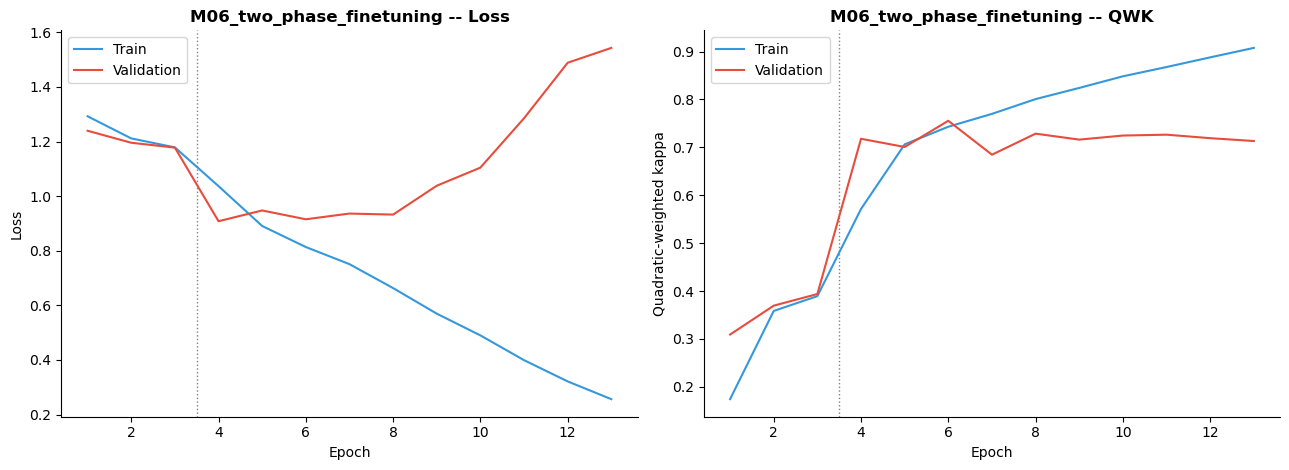

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M06_two_phase_finetuning/training_curves.png


In [18]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")
axes[0].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{RUN_NAME} -- Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["epoch"], history_df["train_qwk"], label="Train", color="#3498DB")
axes[1].plot(history_df["epoch"], history_df["val_qwk"], label="Validation", color="#E74C3C")
axes[1].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Quadratic-weighted kappa")
axes[1].set_title(f"{RUN_NAME} -- QWK", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 17. Validation metrics and confusion matrix

The best checkpoint (by validation QWK, macro-F1 tie-break) is reloaded fresh and re-evaluated
on `val_loader` — **not the internal test set** — to get the metrics this notebook actually
reports: QWK, accuracy, balanced accuracy, macro-F1, macro precision/recall, and the full
per-class classification report, plus raw-count and row-normalised confusion matrices.

In [19]:
best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)

eval_model = build_model(pretrained=False)
eval_model.load_state_dict(best_checkpoint["model_state"])

print(f"Loaded: {BEST_CHECKPOINT_PATH.name}")
print(f"epoch={best_checkpoint['epoch']}  val_qwk={best_checkpoint['val_qwk']:.4f}  "
      f"val_macro_f1={best_checkpoint['val_macro_f1']:.4f}")

final_val_metrics = run_epoch(eval_model, val_loader, train_mode=False)

val_macro_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average="macro", zero_division=0,
)
val_macro_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average="macro", zero_division=0,
)

print()
print("=" * 60)
print(f"  {RUN_NAME} -- VALIDATION RESULTS (best checkpoint)")
print("=" * 60)
print(f"  Val QWK               : {final_val_metrics['qwk']:.4f}")
print(f"  Val accuracy           : {final_val_metrics['accuracy']:.4f}")
print(f"  Val balanced accuracy  : {final_val_metrics['balanced_accuracy']:.4f}")
print(f"  Val macro F1           : {final_val_metrics['macro_f1']:.4f}")
print(f"  Val macro precision    : {val_macro_precision:.4f}")
print(f"  Val macro recall       : {val_macro_recall:.4f}")
print()
print(classification_report(
    final_val_metrics["labels"], final_val_metrics["preds"],
    labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES,
    digits=3, zero_division=0,
))

Loaded: best.pt
epoch=6  val_qwk=0.7554  val_macro_f1=0.5509


eval:   0%|          | 0/165 [00:00<?, ?it/s]


  M06_two_phase_finetuning -- VALIDATION RESULTS (best checkpoint)
  Val QWK               : 0.7554
  Val accuracy           : 0.8178
  Val balanced accuracy  : 0.5539
  Val macro F1           : 0.5509
  Val macro precision    : 0.5778
  Val macro recall       : 0.5539

                  precision    recall  f1-score   support

           No DR      0.862     0.969     0.912      3873
            Mild      0.179     0.052     0.080       368
        Moderate      0.734     0.494     0.590       800
          Severe      0.437     0.598     0.505       127
Proliferative DR      0.677     0.657     0.667       102

        accuracy                          0.818      5270
       macro avg      0.578     0.554     0.551      5270
    weighted avg      0.781     0.818     0.791      5270



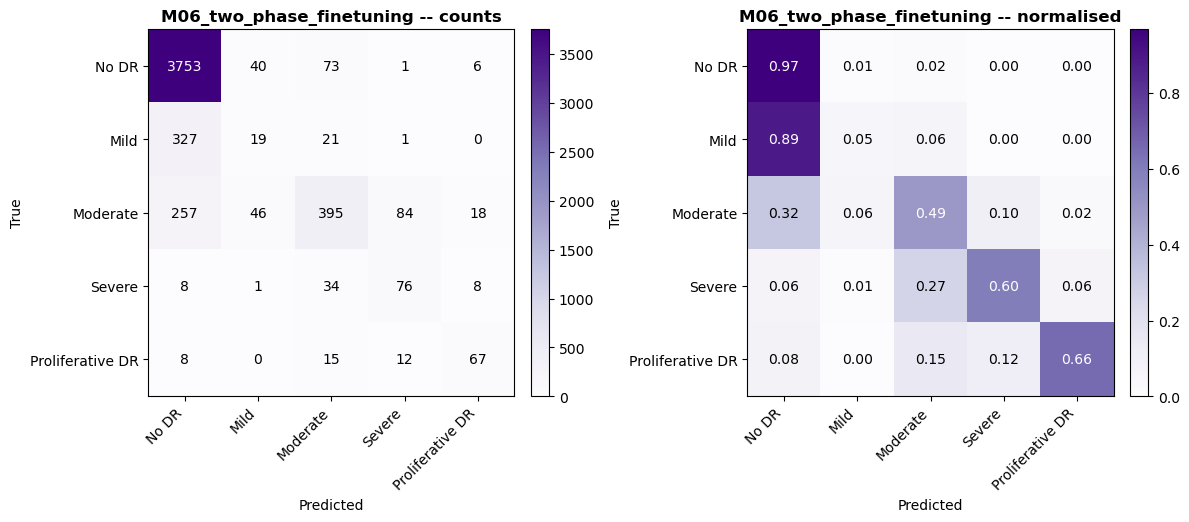

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M06_two_phase_finetuning/confusion_matrix.png


In [20]:
per_class_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)

cm_counts = confusion_matrix(final_val_metrics["labels"], final_val_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, data, fmt, title in [
    (axes[0], cm_counts, "d", f"{RUN_NAME} -- counts"),
    (axes[1], cm_normalised, ".2f", f"{RUN_NAME} -- normalised"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                     color="white" if data[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'confusion_matrix.png'}")

### Mild-DR diagnostic metrics

M06 retains the Mild-specific analysis used in M05 so that the effect of
two-phase fine-tuning can be assessed on Mild recognition as well as overall
validation QWK and macro-F1.

In [ ]:
# M06-specific: this notebook evaluates whether two-phase fine-tuning
# preserves or improves Mild DR recognition. so the
# exact Mild failure pattern is logged directly, not just folded into macro-averaged
# per-class numbers.
labels_array = np.asarray(final_val_metrics["labels"])
preds_array = np.asarray(final_val_metrics["preds"])

absolute_grade_error = np.abs(labels_array - preds_array)

mild_mask = labels_array == 1

mild_precision = float(per_class_precision[1])
mild_recall = float(per_class_recall[1])
mild_f1 = float(per_class_f1[1])

mild_to_no_dr = int(np.sum(mild_mask & (preds_array == 0)))
mild_to_moderate = int(np.sum(mild_mask & (preds_array == 2)))
mild_correct = int(np.sum(mild_mask & (preds_array == 1)))

mean_absolute_grade_error = float(absolute_grade_error.mean())
within_one_grade_accuracy = float((absolute_grade_error <= 1).mean())
large_grade_error_rate = float((absolute_grade_error > 1).mean())

print(f"Mild precision           : {mild_precision:.4f}")
print(f"Mild recall              : {mild_recall:.4f}")
print(f"Mild F1                  : {mild_f1:.4f}")
print(f"Mild correctly predicted : {mild_correct}")
print(f"Mild -> No DR errors     : {mild_to_no_dr}")
print(f"Mild -> Moderate errors  : {mild_to_moderate}")
print(f"Mean absolute grade error: {mean_absolute_grade_error:.4f}")
print(f"Within-one-grade accuracy: {within_one_grade_accuracy:.4f}")
print(f"Large grade-error rate   : {large_grade_error_rate:.4f}")

Mild precision           : 0.1792
Mild recall              : 0.0516
Mild F1                  : 0.0802
Mild correctly predicted : 19
Mild -> No DR errors     : 327
Mild -> Moderate errors  : 21
Mean absolute grade error: 0.2628
Within-one-grade accuracy: 0.9264
Large grade-error rate   : 0.0736


## 18. Save logs and validation predictions

Four artefacts land in `logs/maxvit_tiny/<RUN_NAME>/`: `config.json` (every hyperparameter used, including phase-specific fields for two-phase runs),
`best_metrics.json` (the metrics the checkpoint was actually selected on), `validation_metrics.json`
(the full validation metric suite from Section 17), and `validation_predictions.csv` (every
validation image's prediction, matched back to `image`/`patient_id`/`eye`). `training_history.csv`
was already written incrementally during training. A `change_from_m05` entry also records exactly what changed relative to M05 — parameter `fine_tuning_strategy`, its old and new values — directly in this run's own config.json, rather than relying on someone remembering the diff between two notebooks later.

In [22]:
experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "run_name": RUN_NAME,
    "experiment_type": EXPERIMENT_TYPE,
    "predecessor_experiment": "M05_safe_retinal_augmentation",
    "predecessor_reason": "current_best_maxvit_configuration",
    "primary_metric": "validation_qwk",
    "mild_diagnostic_metric": "validation_mild_f1",

    "model_name": MODEL_NAME,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_epochs": WARMUP_EPOCHS,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_wrs": USE_WRS,
    "label_smoothing": LABEL_SMOOTHING,
    "grad_clip": GRAD_CLIP,
    "qwk_tolerance": QWK_TOLERANCE,
    "selection_metric": "validation_qwk",
    "selection_tiebreak": "validation_macro_f1",
    "training_mode": TRAINING_MODE,
    "preprocessing": "P0",
    "pretrained": True,
    "optimizer": "AdamW",
    "loss_function": LOSS_FUNCTION_LABEL,
    "sampler": "shuffle",
    "scheduler": SCHEDULER_CONFIG,
    "normalisation_mean": list(VIT_MEAN),
    "normalisation_std": list(VIT_STD),
    "training_augmentation": AUGMENTATION_CONFIG,
    "train_class_counts": {
        str(int(label)): int(count)
        for label, count in train_df["level"].value_counts().sort_index().items()
    },
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
}
if TRAINING_MODE == "two_phase":
    experiment_config.update({
        "phase1_epochs": PHASE1_EPOCHS,
        "phase1_head_lr": PHASE1_HEAD_LR,
        "phase2_max_epochs": PHASE2_MAX_EPOCHS,
        "phase2_patience": PHASE2_PATIENCE,
        "backbone_lr": BACKBONE_LR,
        "head_lr": HEAD_LR,
        "phase1": {
            "epochs": PHASE1_EPOCHS,
            "training_scope": "classification_head_only",
            "head_learning_rate": PHASE1_HEAD_LR,
            "scheduler": "constant",
        },
        "phase2": {
            "max_epochs": PHASE2_MAX_EPOCHS,
            "patience": PHASE2_PATIENCE,
            "training_scope": "full_model",
            "backbone_learning_rate": BACKBONE_LR,
            "head_learning_rate": HEAD_LR,
            "scheduler": "CosineAnnealingLR",
        },
    })

if USE_CLASS_WEIGHTS:
    experiment_config.update({
        "class_weight_method": CLASS_WEIGHT_METHOD,
        "class_weight_clip_min": CLASS_WEIGHT_CLIP_MIN,
        "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
        "raw_class_weights": raw_weights.tolist(),
        "clipped_class_weights": clipped_weights.tolist(),
    })


experiment_config["change_from_m05"] = {
    "parameter": "fine_tuning_strategy",
    "m05_value": "single_stage_full_model_finetuning",
    "m06_value": "three_epoch_head_only_warmup_then_full_model_finetuning",
}

with open(RUN_LOG_DIR / "config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)

best_metrics = {
    "epoch": best_checkpoint["epoch"],
    "phase": best_checkpoint.get("phase"),
    "phase_epoch": best_checkpoint.get("phase_epoch"),
    "val_loss": best_checkpoint["val_loss"],
    "val_accuracy": best_checkpoint["val_accuracy"],
    "val_balanced_accuracy": best_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": best_checkpoint["val_macro_f1"],
    "val_qwk": best_checkpoint["val_qwk"],
}
with open(RUN_LOG_DIR / "best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=2)

validation_metrics = {
    "qwk": final_val_metrics["qwk"],
    "accuracy": final_val_metrics["accuracy"],
    "balanced_accuracy": final_val_metrics["balanced_accuracy"],
    "macro_f1": final_val_metrics["macro_f1"],
    "macro_precision": val_macro_precision,
    "macro_recall": val_macro_recall,
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
}
validation_metrics.update({
    "mild_precision": mild_precision,
    "mild_recall": mild_recall,
    "mild_f1": mild_f1,
    "mild_correct": mild_correct,
    "mild_to_no_dr": mild_to_no_dr,
    "mild_to_moderate": mild_to_moderate,
    "mean_absolute_grade_error": mean_absolute_grade_error,
    "within_one_grade_accuracy": within_one_grade_accuracy,
    "large_grade_error_rate": large_grade_error_rate,
})

with open(RUN_LOG_DIR / "validation_metrics.json", "w") as f:
    json.dump(validation_metrics, f, indent=2)

pred_rows = val_df.iloc[final_val_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = final_val_metrics["labels"]
pred_rows["predicted_label"] = final_val_metrics["preds"]
probs_array = np.array(final_val_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]
pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]
pred_rows["grade_error"] = (
    pred_rows["predicted_label"] - pred_rows["true_label"]
)
pred_rows["absolute_grade_error"] = pred_rows["grade_error"].abs()

prediction_columns = [
    "image", "patient_id", "eye", "true_label", "predicted_label",
    "prob_grade_0", "prob_grade_1", "prob_grade_2", "prob_grade_3", "prob_grade_4",
    "correct",
    "grade_error", "absolute_grade_error",
]
pred_rows[prediction_columns].to_csv(RUN_LOG_DIR / "validation_predictions.csv", index=False)

print(f"Saved -> {RUN_LOG_DIR / 'config.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'best_metrics.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'validation_metrics.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'validation_predictions.csv'}  ({len(pred_rows):,} rows)")
print()
print("training_history.csv was already saved incrementally during training.")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M06_two_phase_finetuning/config.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M06_two_phase_finetuning/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M06_two_phase_finetuning/validation_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M06_two_phase_finetuning/validation_predictions.csv  (5,270 rows)

training_history.csv was already saved incrementally during training.


## 19. Experiment conclusion

M06 evaluated two-phase fine-tuning while retaining M05's MaxViT-Tiny
architecture, clipped class-weighted cross-entropy, safe retinal augmentation,
patient-grouped split, P0 preprocessing, optimiser settings and validation
protocol. The only experimental change was the training strategy: three
head-only epochs followed by full-model fine-tuning.

The best checkpoint occurred at global epoch 6, corresponding to Phase-2
epoch 3. It achieved validation QWK of 0.7554, macro-F1 of 0.5509, accuracy
of 0.8178 and balanced accuracy of 0.5539.

Compared with M05, two-phase fine-tuning increased validation QWK from 0.7505
to 0.7554, accuracy from 0.8017 to 0.8178, and balanced accuracy from 0.5509
to 0.5539. However, macro-F1 decreased from 0.5596 to 0.5509.

The class-level analysis revealed an important trade-off. No-DR F1 increased
from 0.903 to 0.912, Severe F1 increased from 0.481 to 0.505, and
Proliferative-DR F1 increased from 0.650 to 0.667. In contrast, Mild F1
decreased substantially from 0.1649 to 0.0802, while Mild recall decreased
from 0.1467 to 0.0516. Only 19 of 368 Mild cases were correctly classified,
and Mild-to-No-DR errors increased from 293 in M05 to 327 in M06.

The selected checkpoint occurred early in Phase 2. Training QWK subsequently
increased from 0.7430 at the selected epoch to 0.9075 by Phase-2 epoch 10,
while validation QWK declined to 0.7132 and validation loss increased to
1.5430. This divergence indicates substantial overfitting after the selected
checkpoint and supports validation-based checkpoint selection and early
stopping.

Under the predefined validation-QWK-first rule, M06 becomes the current
highest-QWK MaxViT configuration. However, M05 remains the stronger
Mild-aware configuration and achieved the higher macro-F1. Two-phase
fine-tuning therefore improved overall ordinal agreement slightly but did
not preserve M05's gain in early-stage DR recognition.

M07 should use M05 as its direct predecessor and add only the ordinal-aware
loss component. This will test whether ordinal supervision can preserve
M05's Mild-DR performance while improving grade-distance awareness and
validation QWK.

**Question answered:** Head-only warm-up followed by full-model fine-tuning
slightly improved validation QWK and overall accuracy, but it substantially
reduced Mild-DR recall and F1. The training strategy therefore produced a
clear overall-performance versus Mild-recognition trade-off.